In [152]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from pathlib import Path
from datetime import datetime
import scipy.stats as st
import statsmodels.api as sm

In [153]:
data_path = Path("../data/processed/NVDA_feature_engineering.parquet")
df = pd.read_parquet(data_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1207 entries, 0 to 1206
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                1207 non-null   datetime64[ns]
 1   adj close           1207 non-null   float64       
 2   close               1207 non-null   float64       
 3   high                1207 non-null   float64       
 4   low                 1207 non-null   float64       
 5   open                1207 non-null   float64       
 6   volume              1207 non-null   int64         
 7   ticker              1207 non-null   object        
 8   daily_rtn           1207 non-null   float64       
 9   excess_return       1207 non-null   float64       
 10  outlier_iqr         1207 non-null   bool          
 11  outlier_winsorize   1207 non-null   float64       
 12  outlier_z           1207 non-null   bool          
 13  mom_5               1207 non-null   float64     

In [154]:
cut=int(len(df)*0.8)
train, test = df.iloc[:cut], df.iloc[cut:]
features=['vol_std_5','mom_5',"log_return"] 
X_tr, X_te = train[features], test[features]
y_tr_reg, y_te_reg = train['next_excess_return'], test['next_excess_return']

In [155]:
reg = Pipeline([('scaler', StandardScaler()), ('linreg', LinearRegression())])
reg.fit(X_tr, y_tr_reg)
pred = reg.predict(X_te)
rmse = np.sqrt(mean_squared_error(y_te_reg, pred))
print('RMSE:', rmse)

RMSE: 0.020212786048193845


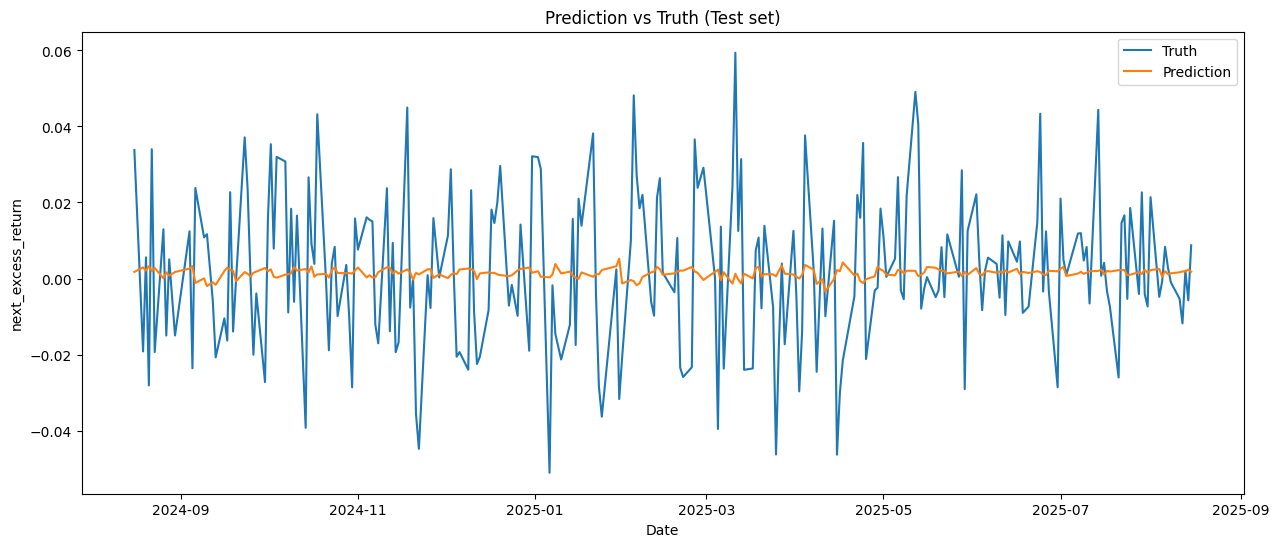

In [156]:
test_plot = test.copy()
test_plot['y_true'] = y_te_reg.values
test_plot['y_pred'] = pred

plt.figure(figsize=(15,6))
plt.plot(test_plot['date'], test_plot['y_true'], label='Truth')
plt.plot(test_plot['date'], test_plot['y_pred'], label='Prediction')
plt.title('Prediction vs Truth (Test set)')
plt.xlabel('Date'); plt.ylabel('next_excess_return')
plt.legend()
plt.show()

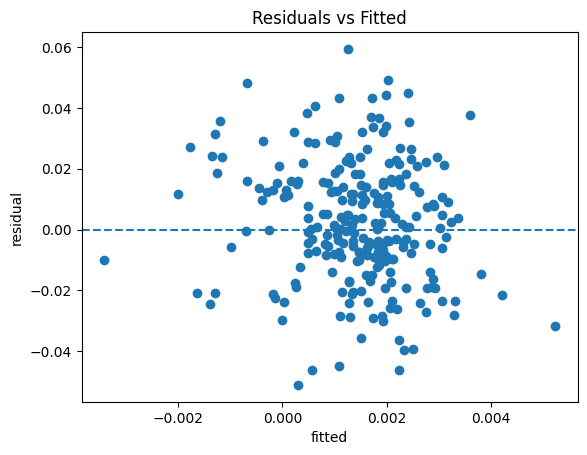

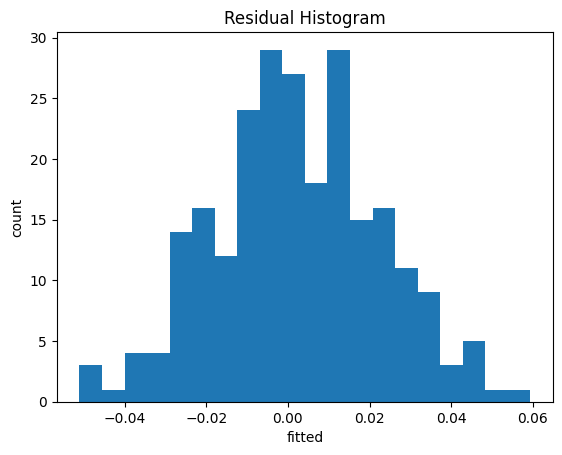

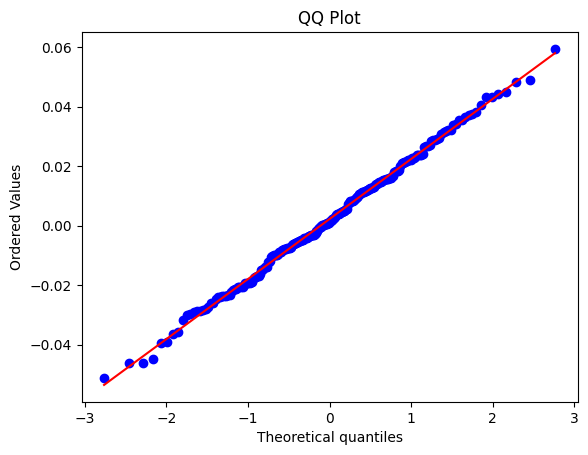

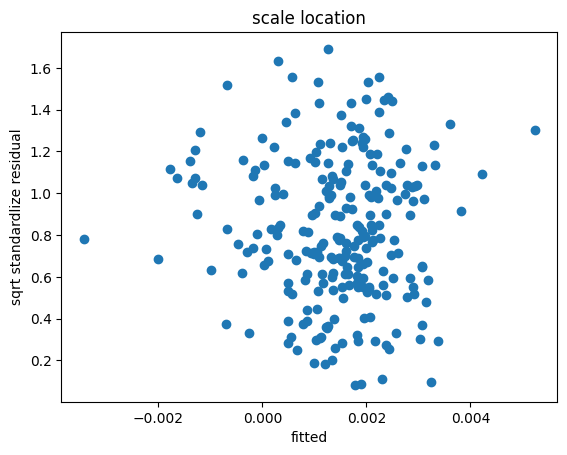

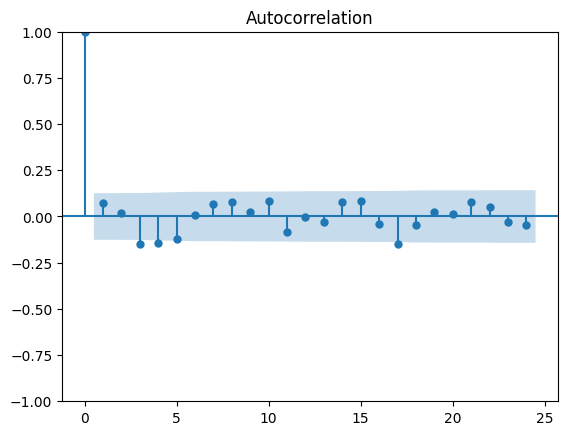

In [157]:
resid = y_te_reg
fitted = pred
sqrt_std_resid = np.sqrt(np.abs((resid-resid.mean()) / np.std(resid)))
plt.figure(); plt.scatter(fitted, resid); plt.axhline(0, ls='--'); plt.title('Residuals vs Fitted'); plt.xlabel("fitted"),plt.ylabel("residual");plt.show()
plt.figure(); plt.hist(resid, bins=20); plt.title('Residual Histogram'); plt.xlabel("fitted"),plt.ylabel("count");plt.show()
plt.figure(); st.probplot(resid, dist='norm', plot=plt); plt.title('QQ Plot'); plt.show()
plt.figure(); plt.scatter(fitted, sqrt_std_resid);plt.title('scale location'); plt.xlabel("fitted"),plt.ylabel("sqrt standardlize residual");plt.show()
fig, ax = plt.subplots()
sm.graphics.tsa.plot_acf(resid,ax=ax)
plt.show()